In [381]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random

The coupling flow

In [382]:
def s(x):
    return 0.03 * jnp.tanh(x)

def t(x):
    return 2.0 * jnp.sin(x)

def forward_coupling(z):
    z1 = z[:, 0]
    z2 = z[:, 1]
    x1 = z1
    s_value = jnp.exp(s(x1))
    t_value = t(x1)
    x2 = z2 * s_value + t_value
    return jnp.stack([x1, x2], axis=1)


To change also the first variable we can permute, beacuse permutation are invertible and they have a det of a jacobian equal to 1.

In [383]:
def permute(z):
    return z[:, ::-1]

We can use the flow more than one time and permute in between one use and another so that we are trasforming everey variable

In [384]:
def flow (z, num_flows, exceptions=False):
    if exceptions or num_flows % 2 == 0:
     for _ in range(num_flows):
        z = permute(z)
        z = forward_coupling(z)
    else : 
       print("Number of flows should be even to maintain the original order of dimensions.")
    return z

In [385]:
def generate_gaussian_data(key, num_samples=100):
    z = random.normal(key, (num_samples, 2))
    return z

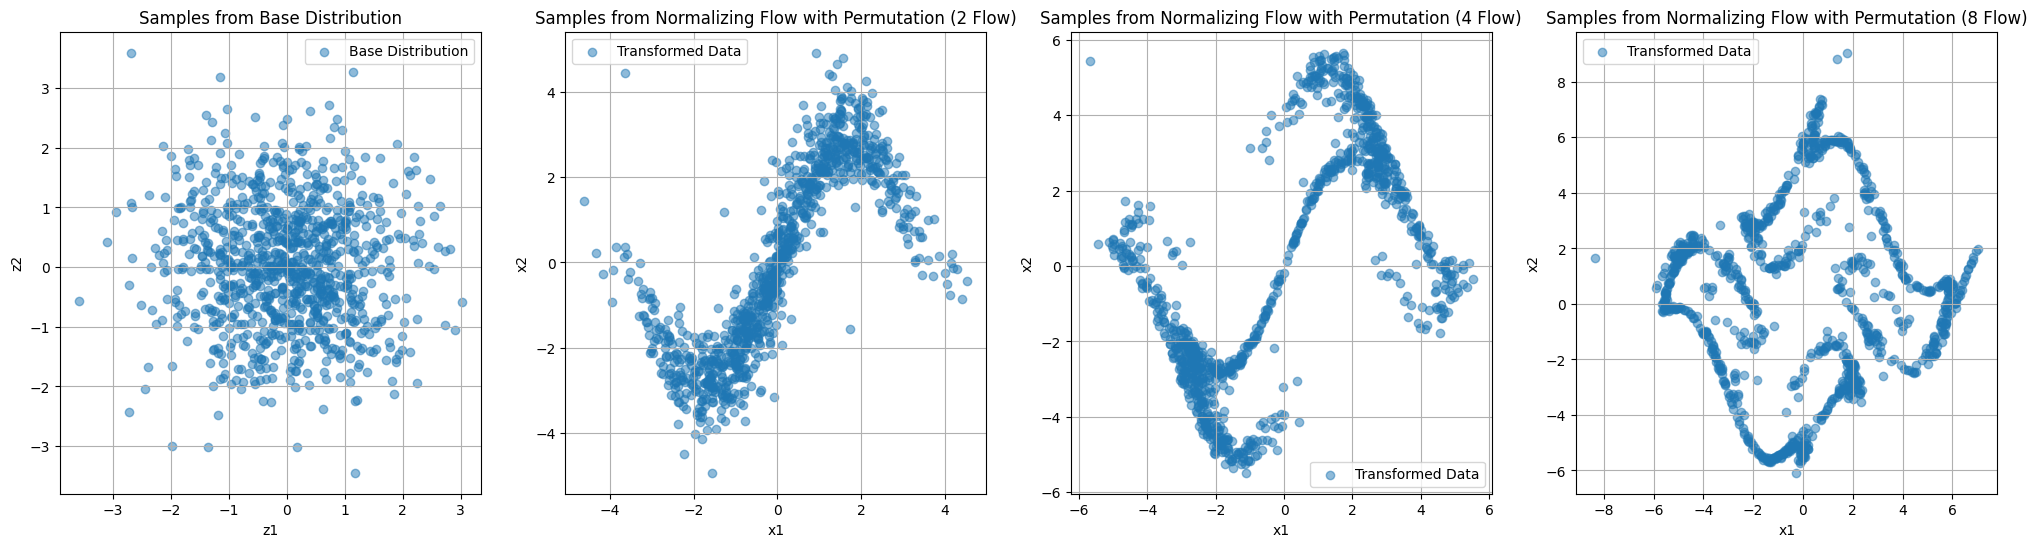

In [386]:
key = random.PRNGKey(0)
key, subkey = random.split(key)
num_samples = 1000
z = generate_gaussian_data(subkey, num_samples)
num_flows = 8
x1 = flow(z, 2, exceptions=True)
x2 = flow(z, 4, exceptions=True)
x3 = flow(z, num_flows, exceptions=True)

#plot
plt.figure(figsize=(25, 6))
plt.subplot(1, 4, 1)
plt.scatter(z[:, 0], z[:, 1], alpha=0.5, label='Base Distribution')
plt.xlabel('z1')
plt.ylabel('z2')
plt.legend()
plt.title('Samples from Base Distribution')
plt.grid()
plt.subplot(1, 4, 2)
plt.scatter(x1[:, 0], x1[:, 1], alpha=0.5, label='Transformed Data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Samples from Normalizing Flow with Permutation (2 Flow)')
plt.grid()
plt.subplot(1, 4, 3)
plt.scatter(x2[:, 0], x2[:, 1], alpha=0.5, label='Transformed Data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Samples from Normalizing Flow with Permutation (4 Flow)')
plt.grid()
plt.subplot(1, 4, 4)
plt.scatter(x3[:, 0], x3[:, 1], alpha=0.5, label='Transformed Data')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title(f'Samples from Normalizing Flow with Permutation ({num_flows} Flow)')
plt.grid()
plt.show()

We are changing all the variables now. Another way to implment this is the mask method.